In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("ab_data.csv")

print("=" * 70)
print("A/B TESTING - WEBSITE CONVERSION ANALYSIS")
print("=" * 70)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

A/B TESTING - WEBSITE CONVERSION ANALYSIS

First 5 rows:
   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1

Dataset shape:
(294478, 5)


In [3]:
# Remove duplicate users
df = df.drop_duplicates(subset=["user_id"])

# Keep only valid A/B groups
df = df[df["group"].isin(["control", "treatment"])]

# Keep only matching landing pages
df = df[
    ((df["group"] == "control") & (df["landing_page"] == "old_page")) |
    ((df["group"] == "treatment") & (df["landing_page"] == "new_page"))
]

print("\nCleaned dataset shape:")
print(df.shape)


Cleaned dataset shape:
(288540, 5)


In [4]:
control = df[df["group"] == "control"]
treatment = df[df["group"] == "treatment"]

n_control = len(control)
n_treatment = len(treatment)

conversions_control = control["converted"].sum()
conversions_treatment = treatment["converted"].sum()

conversion_control = conversions_control / n_control
conversion_treatment = conversions_treatment / n_treatment

print("\n" + "=" * 70)
print("GROUP SUMMARY")
print("=" * 70)

print(f"\nControl Users       : {n_control:,}")
print(f"Control Conversions : {conversions_control:,}")
print(f"Control Conversion Rate : {conversion_control:.4%}")

print(f"\nVariant Users       : {n_treatment:,}")
print(f"Variant Conversions : {conversions_treatment:,}")
print(f"Variant Conversion Rate : {conversion_treatment:.4%}")


GROUP SUMMARY

Control Users       : 144,226
Control Conversions : 17,349
Control Conversion Rate : 12.0290%

Variant Users       : 144,314
Variant Conversions : 17,134
Variant Conversion Rate : 11.8727%


In [5]:
print("\n" + "=" * 70)
print("HYPOTHESIS")
print("=" * 70)

print("""
H0 (Null Hypothesis):
There is no difference in conversion rates between Control and Variant.

H1 (Alternative Hypothesis):
There is a statistically significant difference in conversion rates
between Control and Variant.

Significance Level (alpha) = 0.05
""")



HYPOTHESIS

H0 (Null Hypothesis):
There is no difference in conversion rates between Control and Variant.

H1 (Alternative Hypothesis):
There is a statistically significant difference in conversion rates
between Control and Variant.

Significance Level (alpha) = 0.05



In [6]:
absolute_lift = conversion_treatment - conversion_control

relative_lift = (
    absolute_lift / conversion_control
) * 100

print("=" * 70)
print("CONVERSION LIFT")
print("=" * 70)

print(f"\nAbsolute Conversion Lift : {absolute_lift:.4%}")
print(f"Relative Conversion Lift : {relative_lift:.2f}%")


CONVERSION LIFT

Absolute Conversion Lift : -0.1563%
Relative Conversion Lift : -1.30%


In [7]:
successes = np.array([
    conversions_control,
    conversions_treatment
])

samples = np.array([
    n_control,
    n_treatment
])

z_stat, p_value = proportions_ztest(
    successes,
    samples
)

print("\n" + "=" * 70)
print("TWO-SAMPLE PROPORTION Z-TEST")
print("=" * 70)

print(f"\nZ-Statistic : {z_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("\nDecision: REJECT H0")
    print("The difference is statistically significant.")
else:
    print("\nDecision: FAIL TO REJECT H0")
    print("The difference is not statistically significant.")



TWO-SAMPLE PROPORTION Z-TEST

Z-Statistic : 1.2942
P-Value     : 0.195584

Decision: FAIL TO REJECT H0
The difference is not statistically significant.


In [8]:
contingency_table = pd.crosstab(
    df["group"],
    df["converted"]
)

chi2, chi_p, dof, expected = chi2_contingency(
    contingency_table
)

print("\n" + "=" * 70)
print("CHI-SQUARE TEST")
print("=" * 70)

print("\nContingency Table:")
print(contingency_table)

print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {chi_p:.6f}")
print(f"Degrees of Freedom   : {dof}")

if chi_p < alpha:
    print("\nChi-Square Decision: REJECT H0")
else:
    print("\nChi-Square Decision: FAIL TO REJECT H0")



CHI-SQUARE TEST

Contingency Table:
converted       0      1
group                   
control    126877  17349
treatment  127180  17134

Chi-Square Statistic : 1.6602
P-Value              : 0.197573
Degrees of Freedom   : 1

Chi-Square Decision: FAIL TO REJECT H0


In [9]:
def confidence_interval(conversions, total, confidence=0.95):

    p = conversions / total

    z = norm.ppf(
        1 - (1 - confidence) / 2
    )

    standard_error = np.sqrt(
        p * (1 - p) / total
    )

    margin = z * standard_error

    lower = p - margin
    upper = p + margin

    return lower, upper


control_lower, control_upper = confidence_interval(
    conversions_control,
    n_control
)

treatment_lower, treatment_upper = confidence_interval(
    conversions_treatment,
    n_treatment
)

print("\n" + "=" * 70)
print("95% CONFIDENCE INTERVALS")
print("=" * 70)

print(
    f"\nControl 95% CI : "
    f"{control_lower:.4%} - {control_upper:.4%}"
)

print(
    f"Variant 95% CI : "
    f"{treatment_lower:.4%} - {treatment_upper:.4%}"
)



95% CONFIDENCE INTERVALS

Control 95% CI : 11.8612% - 12.1969%
Variant 95% CI : 11.7058% - 12.0396%


In [10]:
cohen_h = (
    2 * np.arcsin(np.sqrt(conversion_treatment))
    -
    2 * np.arcsin(np.sqrt(conversion_control))
)

print("\n" + "=" * 70)
print("EFFECT SIZE")
print("=" * 70)

print(f"\nCohen's h : {cohen_h:.4f}")

if abs(cohen_h) < 0.2:
    effect_interpretation = "Small effect"
elif abs(cohen_h) < 0.5:
    effect_interpretation = "Medium effect"
else:
    effect_interpretation = "Large effect"

print(f"Interpretation : {effect_interpretation}")


EFFECT SIZE

Cohen's h : -0.0048
Interpretation : Small effect


In [11]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline_rate = conversion_control

target_rate = conversion_treatment

effect = proportion_effectsize(
    baseline_rate,
    target_rate
)

power_analysis = NormalIndPower()

required_sample = power_analysis.solve_power(
    effect_size=abs(effect),
    alpha=0.05,
    power=0.80,
    ratio=1
)

print("\n" + "=" * 70)
print("SAMPLE SIZE ANALYSIS")
print("=" * 70)

print(
    f"\nEstimated sample size per group "
    f"for 80% power: {required_sample:,.0f}"
)

print(
    f"Actual Control sample: {n_control:,}"
)

print(
    f"Actual Variant sample: {n_treatment:,}"
)


SAMPLE SIZE ANALYSIS

Estimated sample size per group for 80% power: 676,008
Actual Control sample: 144,226
Actual Variant sample: 144,314


In [12]:
print("\n" + "=" * 70)
print("EXECUTIVE DECISION MEMO")
print("=" * 70)

print("\nRecommendation:")

if p_value < alpha and conversion_treatment > conversion_control:

    print("""
LAUNCH VARIANT B

The Variant demonstrates a statistically significant improvement
in conversion rate compared with the Control.

Reason:
- P-value is below 0.05
- Conversion rate increased
- Statistical evidence supports the observed improvement
- Variant should be considered for production rollout
""")

elif p_value < alpha and conversion_treatment < conversion_control:

    print("""
KEEP CONTROL A

The Variant performs significantly worse than the Control.

Recommendation:
Do not launch Variant B. Continue using Control A.
""")

else:

    print("""
KEEP CONTROL A FOR NOW

The observed conversion difference is not statistically significant.

Recommendation:
Do not make a permanent rollout decision yet.
Consider collecting more data or running another experiment.
""")



EXECUTIVE DECISION MEMO

Recommendation:

KEEP CONTROL A FOR NOW

The observed conversion difference is not statistically significant.

Recommendation:
Do not make a permanent rollout decision yet.
Consider collecting more data or running another experiment.



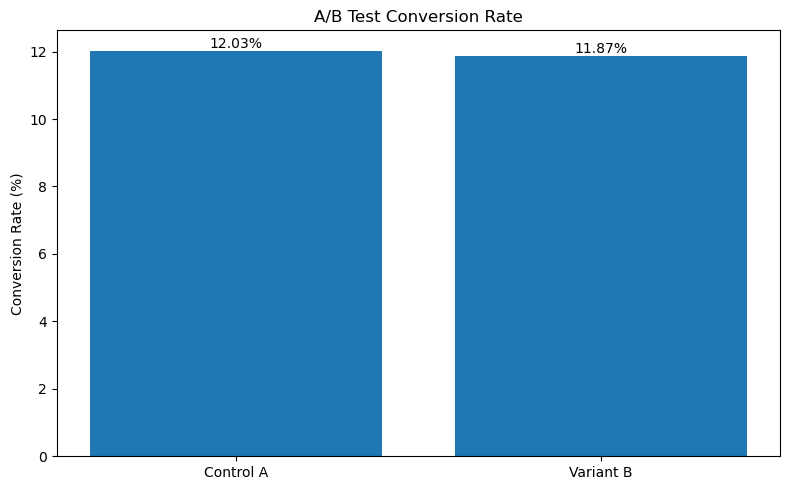

In [13]:
groups = ["Control A", "Variant B"]

conversion_rates = [
    conversion_control * 100,
    conversion_treatment * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    groups,
    conversion_rates
)

plt.title("A/B Test Conversion Rate")
plt.ylabel("Conversion Rate (%)")

for bar, rate in zip(bars, conversion_rates):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "conversion_rate_comparison.png",
    dpi=300
)

plt.show()

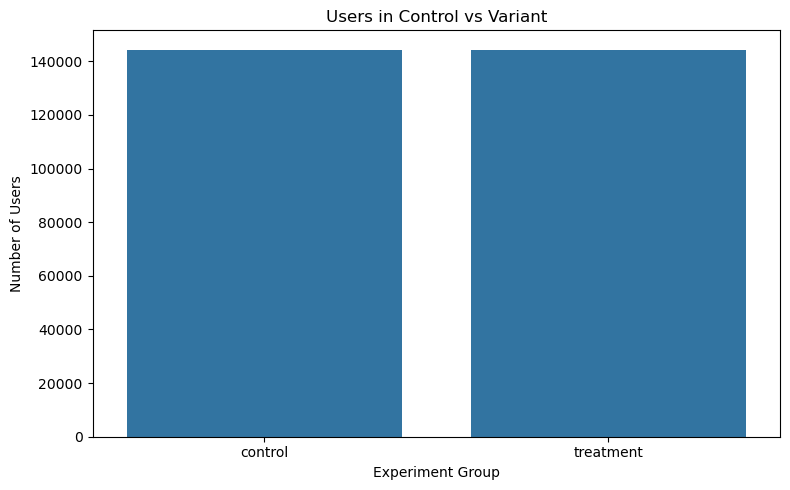

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="group"
)

plt.title("Users in Control vs Variant")

plt.xlabel("Experiment Group")

plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    "user_distribution.png",
    dpi=300
)

plt.show()

In [18]:
print("FINAL A/B TEST SUMMARY")
print("=" * 70)

print(f"""
Control Conversion Rate : {conversion_control:.4%}

Variant Conversion Rate : {conversion_treatment:.4%}

Relative Lift            : {relative_lift:.2f}%

Z-Statistic              : {z_stat:.4f}

Z-Test P-Value            : {p_value:.6f}

Chi-Square P-Value        : {chi_p:.6f}

Cohen's h                 : {cohen_h:.4f}

Control 95% CI            : {control_lower:.4%} - {control_upper:.4%}

Variant 95% CI            : {treatment_lower:.4%} - {treatment_upper:.4%}


""")

print("=" * 70)
print("Analysis Completed Successfully!")
print("=" * 70)

FINAL A/B TEST SUMMARY

Control Conversion Rate : 12.0290%

Variant Conversion Rate : 11.8727%

Relative Lift            : -1.30%

Z-Statistic              : 1.2942

Z-Test P-Value            : 0.195584

Chi-Square P-Value        : 0.197573

Cohen's h                 : -0.0048

Control 95% CI            : 11.8612% - 12.1969%

Variant 95% CI            : 11.7058% - 12.0396%



Analysis Completed Successfully!
